In [1]:
import networkx as nx
import numpy as np
from itertools import combinations

In [32]:
def school_friendship_network(n, s, k, p):

    # Number of students per class
    n_s = n // s

    # If large enough for there to be subnetworks...
    if n_s - 1 > 4 * k:

        # Number of subnetworks
        f = (n_s - 1) // (2 * k)
        # Min. number of students in each subnetwork
        n_f = n_s // f
        # Probability that any 2 students in the same subnetwork are friends
        p_f = k / (n_f - 1)

        # For each class in the school...
        g_list = []
        for i in range(s):
        
            # Create Erdos-Renyi graphs for each subnetwork
            h_list = []
            for snw in range(n_s % f):
                h_list.append(nx.erdos_renyi_graph(n_f+1, p_f))
            for snw in range(n_s % f, n_f):
                h_list.append(nx.erdos_renyi_graph(n_f, p_f))
                
            # Merge graphs
            H = h_list[0]
            for snw in range(1,f):
                H = nx.disjoint_union(H, h_list[snw])
    
            # Rewire edges of H
            original_edges = list(H.edges)
            all_edges = list(combinations(list(H.nodes), r=2))
            for edge in original_edges:
                # Randomly rewire with probability p
                if np.random.binomial(1, p):
                    H.remove_edge(edge[0], edge[1])
                    poss_edges = list(set(all_edges).difference(list(H.edges)))
                    index = np.random.randint(len(poss_edges))
                    new_edge = poss_edges[index]
                    H.add_edge(new_edge[0], new_edge[1])

            # Store graph for class
            g_list.append(H)
                
    # Else no subnetworks and entire class an ER network
    else:

        # Probability that any 2 students in the same subnetwork are friends
        p_s = k / (n_s - 1)

        # For each class in the school...
        g_list = []
        for i in range(s):
    
            # Create an Erdos-Renyi graph for the class and store
            g_list.append(nx.erdos_renyi_graph(n_s, p_s))

    # Merge classroom graphs
    G = g_list[0]
    for i in range(1,s):
        G = nx.disjoint_union(G, g_list[i])
        
    # Randomly rewire within the entire school
    original_edges = list(G.edges)
    all_edges = list(combinations(list(G.nodes), r=2))
    for edge in original_edges:
        # Randomly rewire with probability p
        if np.random.binomial(1, p):
            G.remove_edge(edge[0], edge[1])
            poss_edges = list(set(all_edges).difference(list(G.edges)))
            index = np.random.randint(len(poss_edges))
            new_edge = poss_edges[index]
            G.add_edge(new_edge[0], new_edge[1])

    # Draw the graph
    nx.draw(G)

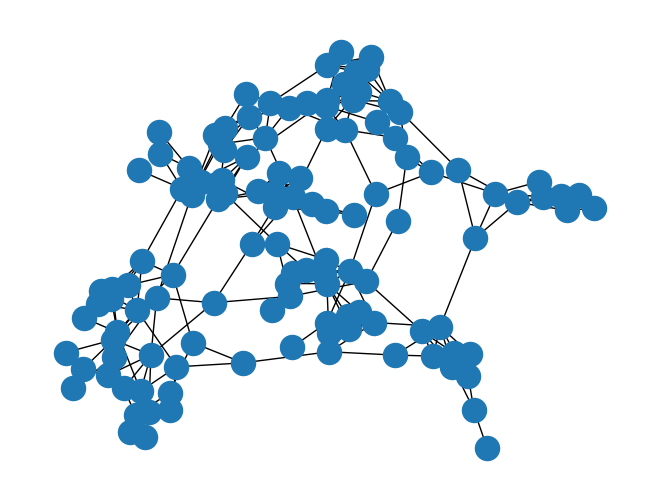

In [34]:
school_friendship_network(120, 4, 4, 0.1)